# Dashboard Observer (Phase 6: Matrix + Observer Metrics)

This notebook subscribes to observer metrics and renders a lightweight live dashboard.

Phase 6 scope:
- Subscribe: `.../sim/observer/metrics`
- Render with a matplotlib matrix + per-tick textual summaries

In [4]:
# Cell purpose: import dependencies and connect to MQTT using project config.
from datetime import datetime, timezone
import json
import time

import ipywidgets as widgets
import matplotlib.pyplot as plt
from IPython import get_ipython
from IPython.display import Markdown, clear_output, display

from simulated_city.config import load_config
from simulated_city.mqtt import MqttConnector, MqttPublisher

config = load_config()
print(f"Loaded config. Primary MQTT profile: {config.mqtt.host}:{config.mqtt.port}")

connector = MqttConnector(config.mqtt, client_id_suffix="dashboard-observer-phase6")
connector.connect()
connected = connector.wait_for_connection(timeout=5)
print(f"MQTT connected: {connected}")

publisher = MqttPublisher(connector)

Loaded config. Primary MQTT profile: 127.0.0.1:1883
MQTT connected: True


In [5]:
# Cell purpose: define topic names, matrix labels, and start-control button.
base_topic = config.mqtt.base_topic.rstrip("/")
observer_metrics_topic = f"{base_topic}/sim/observer/metrics"
start_control_topic = f"{base_topic}/sim/control/commands"

matrix_row_labels = ["Population", "Environment", "Dynamics"]
matrix_col_labels = ["Signal A", "Signal B", "Signal C"]
start_commands_sent = 0

start_button = widgets.Button(
    description="Start Simulation",
    button_style="success",
    tooltip="Send start command to simulation agents",
)


def _on_start_button_clicked(_):
    global start_commands_sent

    command_payload = {
        "command": "start",
        "source": "dashboard_observer",
        "timestamp_utc": datetime.now(timezone.utc).isoformat(),
    }
    result = publisher.publish_json(
        start_control_topic,
        json.dumps(command_payload),
        qos=1,
        retain=True,
    )
    start_commands_sent += 1
    print(
        f"Sent START command #{start_commands_sent} to {start_control_topic} "
        f"(qos=1 retain=True rc={result.rc})"
    )


start_button.on_click(_on_start_button_clicked)
display(start_button)

print("Matrix dashboard configured (matplotlib).")
print(f"Subscribed topic target: {observer_metrics_topic}")
print(f"Start command topic: {start_control_topic}")

Button(button_style='success', description='Start Simulation', style=ButtonStyle(), tooltip='Send start comman…

Matrix dashboard configured (matplotlib).
Subscribed topic target: simulated-city/sim/observer/metrics
Start command topic: simulated-city/sim/control/commands


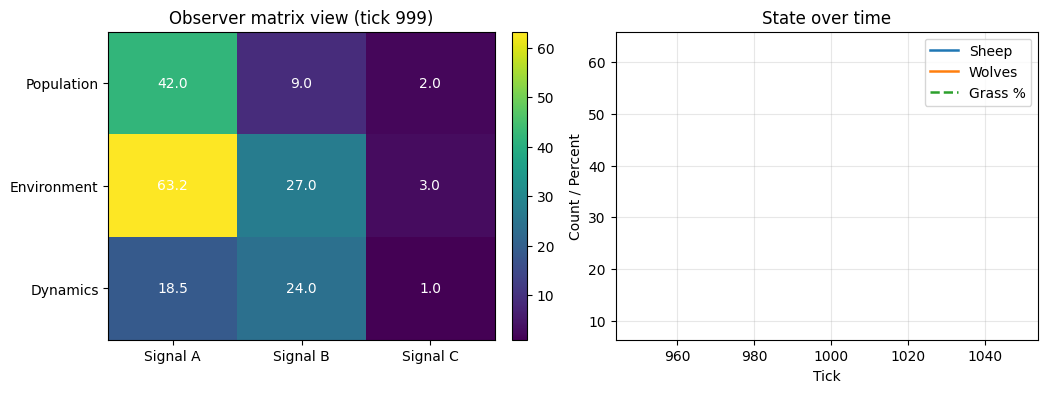

### Observer Metrics (tick 999)
- Sheep: 42
- Wolves: 9
- Sheep average energy: 18.5
- Grass coverage: 63.2%
- Occupancy estimate: 0.27
- Events (births/deaths/predation): 2/1/3
- Controller reason: test-message
- Last update: 2026-03-05T11:25:55

Rendered observer metrics message #1


In [ ]:
# Cell purpose: subscribe to observer metrics and store updates for loop-driven rendering.
latest_metrics = None
metrics_count = 0
last_rendered_count = 0
history_ticks = []
history_sheep = []
history_wolves = []
history_grass_pct = []
max_history_points = 500
render_callback_pending = False


def _build_metric_matrix(population, energy, grass, events, occupancy):
    return [
        [
            int(population.get("sheep", 0)),
            int(population.get("wolves", 0)),
            int(events.get("births", 0)),
        ],
        [
            float(grass.get("coverage_pct", 0.0)),
            float(occupancy.get("estimated_ratio", 0.0)) * 100.0,
            int(events.get("predation", 0)),
        ],
        [
            float(energy.get("sheep_average", 0.0)),
            float(energy.get("wolves_average", 0.0)),
            int(events.get("deaths", 0)),
        ],
    ]


def _render_dashboard(metrics):
    tick = metrics.get("tick", 0)
    population = metrics.get("population", {})
    energy = metrics.get("energy", {})
    grass = metrics.get("grass", {})
    events = metrics.get("events", {})
    occupancy = metrics.get("occupancy", {})
    controller = metrics.get("controller", {})

    sheep_count = int(population.get("sheep", 0))
    wolf_count = int(population.get("wolves", 0))
    grass_pct = float(grass.get("coverage_pct", 0.0))

    matrix = _build_metric_matrix(population, energy, grass, events, occupancy)

    text = [
        f"### Observer Metrics (tick {tick})",
        f"- Sheep: {sheep_count}",
        f"- Wolves: {wolf_count}",
        f"- Sheep average energy: {energy.get('sheep_average', 0)}",
        f"- Grass coverage: {grass_pct}%",
        f"- Occupancy estimate: {occupancy.get('estimated_ratio', 0)}",
        f"- Events (births/deaths/predation): {events.get('births', 0)}/{events.get('deaths', 0)}/{events.get('predation', 0)}",
        f"- Controller reason: {controller.get('latest_reason', 'baseline')}",
        f"- Last update: {datetime.now().isoformat(timespec='seconds')}",
    ]

    clear_output(wait=True)

    fig, (ax_matrix, ax_trend) = plt.subplots(1, 2, figsize=(12, 4))
    heatmap = ax_matrix.imshow(matrix, cmap="viridis", aspect="auto")
    ax_matrix.set_title(f"Observer matrix view (tick {tick})")
    ax_matrix.set_yticks(range(len(matrix_row_labels)), labels=matrix_row_labels)
    ax_matrix.set_xticks(range(len(matrix_col_labels)), labels=matrix_col_labels)

    for row_index, row in enumerate(matrix):
        for col_index, value in enumerate(row):
            ax_matrix.text(col_index, row_index, f"{value:.1f}", ha="center", va="center", color="white")

    fig.colorbar(heatmap, ax=ax_matrix, fraction=0.046, pad=0.04)

    ax_trend.plot(history_ticks, history_sheep, label="Sheep", linewidth=1.8)
    ax_trend.plot(history_ticks, history_wolves, label="Wolves", linewidth=1.8)
    ax_trend.plot(history_ticks, history_grass_pct, label="Grass %", linewidth=1.8, linestyle="--")
    ax_trend.set_title("State over time")
    ax_trend.set_xlabel("Tick")
    ax_trend.set_ylabel("Count / Percent")
    ax_trend.grid(alpha=0.3)
    ax_trend.legend(loc="best")
    display(fig)
    plt.close(fig)
    display(Markdown("\n".join(text)))


def _render_if_new_metrics():
    global last_rendered_count, render_callback_pending

    render_callback_pending = False
    if latest_metrics is None or metrics_count <= last_rendered_count:
        return

    _render_dashboard(latest_metrics)
    last_rendered_count = metrics_count
    print(f"Rendered observer metrics message #{last_rendered_count}")


def _schedule_render():
    global render_callback_pending

    if render_callback_pending:
        return

    ip = get_ipython()
    if ip is None or getattr(ip, "kernel", None) is None:
        return

    render_callback_pending = True
    ip.kernel.io_loop.add_callback(_render_if_new_metrics)


def on_message(client, userdata, msg):
    global latest_metrics, metrics_count

    try:
        payload = json.loads(msg.payload.decode("utf-8"))
    except Exception:
        print(f"Skipping non-JSON payload on topic {msg.topic}")
        return

    latest_metrics = payload
    metrics_count += 1

    population = payload.get("population", {})
    grass = payload.get("grass", {})
    history_ticks.append(int(payload.get("tick", metrics_count)))
    history_sheep.append(int(population.get("sheep", 0)))
    history_wolves.append(int(population.get("wolves", 0)))
    history_grass_pct.append(float(grass.get("coverage_pct", 0.0)))

    if len(history_ticks) > max_history_points:
        history_ticks.pop(0)
        history_sheep.pop(0)
        history_wolves.pop(0)
        history_grass_pct.pop(0)
    print(f"Received observer metrics message #{metrics_count} (tick={payload.get('tick', '?')})")
    _schedule_render()


connector.client.on_message = on_message
connector.client.subscribe(observer_metrics_topic, qos=0)
print("Subscription active. Waiting for observer metrics...")
print("Dashboard auto-render is active; no separate loop cell is required.")

In [4]:
# Cell purpose: optional keep-alive loop for manual runs; auto-render is already active in the subscribe cell.
print("Auto-render mode is active.")
print("If you want a manual keep-alive loop, run this cell and interrupt to stop.")
try:
    while True:
        time.sleep(1.0)
except KeyboardInterrupt:
    print("Stopping manual keep-alive loop.")

Dashboard loop running. Interrupt the cell to stop.
Stopping manual keep-alive loop.
